<a href="https://colab.research.google.com/github/KasunUdayanga/NER-Sinhala-political-comment-identifier/blob/main/Notebooks/infoxml-base.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Load and Inspect Dataset

### Subtask:
Load the `sinhala_dataset_balanced.conll` file and inspect its structure. This will involve understanding the CoNLL format, identifying sentences, and extracting words and their corresponding labels to prepare for tokenization and model input.


In [5]:
import os
from google.colab import drive

if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

sentences = []
current_sentence = []

with open('/content/drive/MyDrive/ColabNotebooks/sinhala_dataset_balanced.conll', 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if line:
            # Assuming CoNLL format: word\tlabel or word label
            parts = line.split('\t')
            if len(parts) == 2:
                word, label = parts
                current_sentence.append((word, label))
            else:
                # Handle cases where separator might be space or other characters
                parts = line.split(' ')
                if len(parts) == 2:
                    word, label = parts
                    current_sentence.append((word, label))
                else:
                    # Skip malformed lines or log a warning if necessary
                    pass
        else:
            # Blank line indicates end of a sentence
            if current_sentence:
                sentences.append(current_sentence)
                current_sentence = []

# Add the last sentence if the file doesn't end with a blank line
if current_sentence:
    sentences.append(current_sentence)


print(f"Total sentences parsed: {len(sentences)}")
print("\nFirst 3 sentences with words and labels:")
for i, sentence in enumerate(sentences[:3]):
    print(f"\n--- Sentence {i+1} ---")
    for word, label in sentence:
        print(f"Word: '{word}', Label: '{label}'")

Mounted at /content/drive
Total sentences parsed: 9633

First 3 sentences with words and labels:

--- Sentence 1 ---
Word: 'පාලමුන', Label: 'B-LOC'

--- Sentence 2 ---
Word: 'ඔබතමයි', Label: 'B-Other'
Word: 'කාරයෝන්ට', Label: 'B-Other'
Word: 'රාජපක්ෂලාටම්', Label: 'B-PER'
Word: 'හර්ශ', Label: 'B-PER'
Word: 'විපක්ශයට', Label: 'B-ORG'
Word: 'අවලද', Label: 'B-Other'
Word: 'දැම්මාඇත්ත', Label: 'B-Other'
Word: 'ඩොබිලාට', Label: 'B-Other'
Word: 'පැන්චො', Label: 'B-Other'

--- Sentence 3 ---
Word: 'මකුලෑව', Label: 'B-LOC'


**Reasoning**:
I need to load the CoNLL file, parse its content, and store it in a structured format as per the instructions. This involves iterating through the file line by line to identify words, labels, and sentence boundaries.



## Load Pre-trained Model and Tokenizer

### Subtask:
Load the `microsoft/infoxlm-base` pre-trained model and its associated tokenizer using the `transformers` library. This step ensures we have the correct vocabulary and model architecture for fine-tuning.


**Reasoning**:
Before importing and using the `transformers` library, I need to ensure it is installed in the environment. This is a prerequisite for loading the tokenizer and model.



In [6]:
pip install transformers

In [7]:
from transformers import AutoTokenizer, AutoModelForTokenClassification

model_name = "microsoft/infoxlm-base"

# Load the tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_name)
print(f"Tokenizer '{model_name}' loaded successfully.")

# Extract unique labels from the sentences data
all_labels = sorted(list(set(label for sentence in sentences for _, label in sentence)))

# Create label-to-id and id-to-label mappings
label_to_id = {label: i for i, label in enumerate(all_labels)}
id_to_label = {i: label for i, label in enumerate(all_labels)}
num_labels = len(all_labels)

print(f"\nFound {num_labels} unique labels: {all_labels}")
print(f"Label to ID mapping: {label_to_id}")
print(f"ID to Label mapping: {id_to_label}")

# Load the pre-trained model for token classification
model = AutoModelForTokenClassification.from_pretrained(
    model_name,
    num_labels=num_labels,
    id2label=id_to_label,
    label2id=label_to_id
)
print(f"\nModel '{model_name}' for token classification loaded successfully with {num_labels} labels.")

config.json:   0%|          | 0.00/512 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer 'microsoft/infoxlm-base' loaded successfully.

Found 9 unique labels: ['B-LOC', 'B-ORG', 'B-Other', 'B-PER', 'I-LOC', 'I-ORG', 'I-Other', 'I-PER', 'O']
Label to ID mapping: {'B-LOC': 0, 'B-ORG': 1, 'B-Other': 2, 'B-PER': 3, 'I-LOC': 4, 'I-ORG': 5, 'I-Other': 6, 'I-PER': 7, 'O': 8}
ID to Label mapping: {0: 'B-LOC', 1: 'B-ORG', 2: 'B-Other', 3: 'B-PER', 4: 'I-LOC', 5: 'I-ORG', 6: 'I-Other', 7: 'I-PER', 8: 'O'}


pytorch_model.bin:   0%|          | 0.00/942M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/942M [00:00<?, ?B/s]

Some weights of XLMRobertaForTokenClassification were not initialized from the model checkpoint at microsoft/infoxlm-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Model 'microsoft/infoxlm-base' for token classification loaded successfully with 9 labels.


## Preprocess Dataset for Fine-tuning

### Subtask:
Tokenize the words from the dataset using the loaded tokenizer. Crucially, align the labels from the CoNLL file with the tokenized inputs, handling subword tokens correctly. This will create input IDs, attention masks, and aligned labels suitable for model training.


**Reasoning**:
The previous code block contained markdown in a code cell, leading to a `SyntaxError`. To correctly display the subtask description and proceed with the data preprocessing, I will first correct the previous cell to be a markdown cell and then create a new code cell to implement the label alignment and tokenization logic as per the instructions.



In [8]:
input_ids = []
attention_masks = []
aligned_labels = []

for sentence in sentences:
    words = [word for word, label in sentence]
    labels = [label for word, label in sentence]

    # Tokenize words and get word IDs
    # is_split_into_words=True indicates that the input is a list of words
    tokenized_input = tokenizer(words, is_split_into_words=True, truncation=True, padding='max_length', max_length=128)

    word_ids = tokenized_input.word_ids(batch_index=0)

    previous_word_idx = None
    label_ids = []
    for word_idx in word_ids:
        # Special tokens have a word ID of None. We set the label to -100 so they are ignored in the loss function.
        if word_idx is None:
            label_ids.append(-100)
        # We set the label for the first token of each word.
        elif word_idx != previous_word_idx:
            label_ids.append(label_to_id[labels[word_idx]])
        # For other tokens in a word, we set the label to -100.
        else:
            label_ids.append(-100)
        previous_word_idx = word_idx

    input_ids.append(tokenized_input['input_ids'])
    attention_masks.append(tokenized_input['attention_mask'])
    aligned_labels.append(label_ids)

print(f"Processed {len(input_ids)} sentences.")
print(f"First sentence input IDs: {input_ids[0]}")
print(f"First sentence attention mask: {attention_masks[0]}")
print(f"First sentence aligned labels: {aligned_labels[0]}")

# Decode first tokenized sentence for verification
decoded_tokens = tokenizer.convert_ids_to_tokens(input_ids[0])
print(f"\nDecoded tokens for first sentence: {decoded_tokens}")
print(f"Corresponding aligned labels: {[id_to_label[l] if l != -100 else 'IGNORE' for l in aligned_labels[0]]}")

Processed 9633 sentences.
First sentence input IDs: [0, 237394, 80078, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
First sentence attention mask: [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
First sentence aligned labels: [-100, 0, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -

**Reasoning**:
The previous step successfully processed the raw sentences into tokenized inputs and aligned labels. To prepare this data for model training, I need to convert these lists into PyTorch tensors and then create a PyTorch Dataset object. This will allow for efficient batching and feeding of data to the model during training.



In [9]:
import torch
from torch.utils.data import TensorDataset, random_split

# Convert lists to PyTorch tensors
input_ids_tensor = torch.tensor(input_ids)
attention_masks_tensor = torch.tensor(attention_masks)
aligned_labels_tensor = torch.tensor(aligned_labels)

# Create a TensorDataset
dataset = TensorDataset(input_ids_tensor, attention_masks_tensor, aligned_labels_tensor)

print(f"Total dataset size: {len(dataset)}")
print(f"Example input_ids tensor shape: {input_ids_tensor[0].shape}")
print(f"Example attention_mask tensor shape: {attention_masks_tensor[0].shape}")
print(f"Example aligned_labels tensor shape: {aligned_labels_tensor[0].shape}")

# Define the proportion for training and validation
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

# Split the dataset into training and validation sets
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

print(f"Training dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")

Total dataset size: 9633
Example input_ids tensor shape: torch.Size([128])
Example attention_mask tensor shape: torch.Size([128])
Example aligned_labels tensor shape: torch.Size([128])
Training dataset size: 7706
Validation dataset size: 1927


## Configure Training and Fine-tune Model

### Subtask:
Define the training arguments, including parameters like batch size, learning rate, and number of epochs. Then, fine-tune the `microsoft/infoxlm-base` model on the preprocessed dataset using a `Trainer` from the `transformers` library.


In [16]:
!pip install seqeval

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for seqeval: filename=seqeval-1.2.2-py3-none-any.whl size=16162 sha256=64f9b03104b715b3a908642521324196493a0d3c8c6e13ca208cbfcc9008d8ad
  Stored in directory: /root/.cache/pip/wheels/5f/b8/73/0b2c1a76b701a677653dd79ece07cfabd7457989dbfbdcd8d7
Successfully built seqeval


In [17]:
import numpy as np
from seqeval.metrics import f1_score, precision_score, recall_score

label_list = list(model.config.id2label.values())

def compute_metrics(p):
    predictions, labels = p
    predictions = np.argmax(predictions, axis=2)

    true_predictions = [
        [label_list[p] for (p, l) in zip(pred, lab) if l != -100]
        for pred, lab in zip(predictions, labels)
    ]
    true_labels = [
        [label_list[l] for (p, l) in zip(pred, lab) if l != -100]
        for pred, lab in zip(predictions, labels)
    ]

    return {
        "precision": precision_score(true_labels, true_predictions),
        "recall": recall_score(true_labels, true_predictions),
        "f1": f1_score(true_labels, true_predictions),
    }

import torch
from transformers import TrainingArguments, Trainer, DataCollatorForTokenClassification
from transformers.trainer_utils import IntervalStrategy
from torch.utils.data import Dataset as TorchDataset # Import torch's Dataset to avoid name conflict

# Define a custom Dataset class to return dictionaries
class DictOutputDataset(TorchDataset):
    def __init__(self, subset_dataset):
        self.subset_dataset = subset_dataset

    def __len__(self):
        return len(self.subset_dataset)

    def __getitem__(self, idx):
        input_ids, attention_mask, labels = self.subset_dataset[idx]
        return {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "labels": labels
        }

# Define training arguments
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=4,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,   # FIXED
    logging_steps=50,
)



# Initialize Data Collator
data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)

# Wrap the existing train_dataset and val_dataset with DictOutputDataset
train_dataset_dict = DictOutputDataset(train_dataset)
val_dataset_dict = DictOutputDataset(val_dataset)

# Create a Trainer object
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset_dict,
    eval_dataset=val_dataset_dict,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)


# Start training
trainer.train()

print("Model training initiated.")


/tmp/ipython-input-4259683230.py:72: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Precision,Recall,F1
1,0.230800,1.215021,0.768179,0.940327,0.845580
2,0.387300,0.531346,0.832909,0.923976,0.876082
3,0.287100,0.511588,0.856611,0.914731,0.884718
4,0.284600,0.503329,0.862768,0.914120,0.887702


Model training initiated.


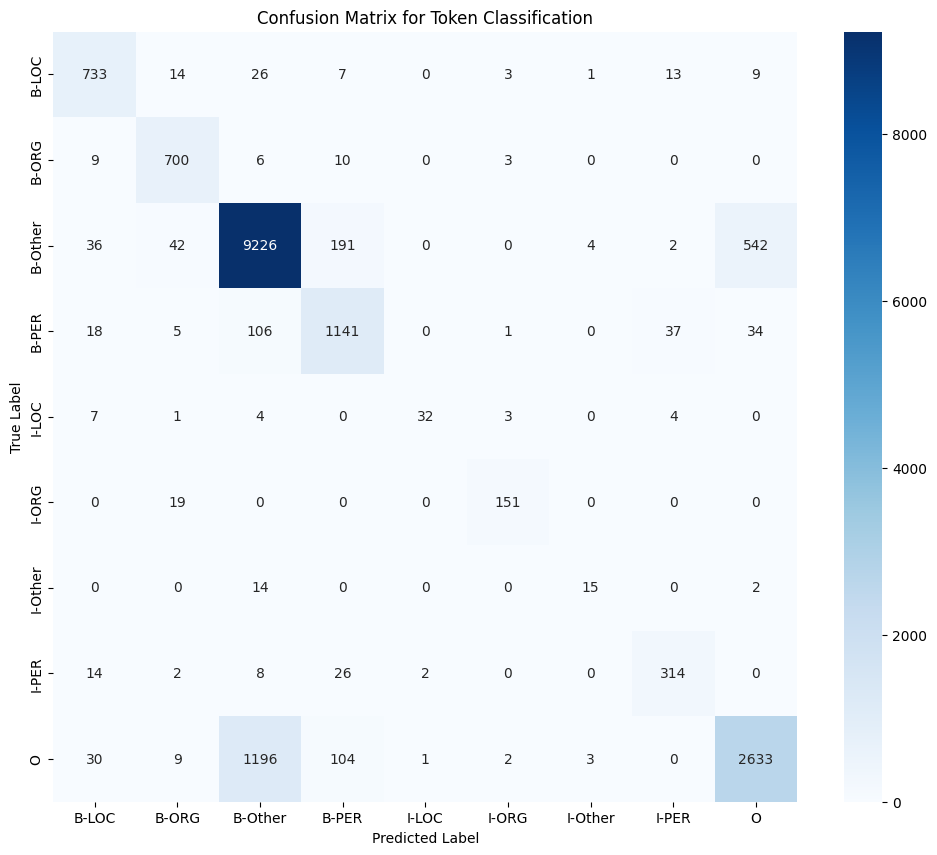

In [18]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

# Get predictions from the trainer on the validation dataset
# The val_dataset_dict should be used as it's the wrapped dataset for the Trainer
predictions_output = trainer.predict(val_dataset_dict)
predictions = predictions_output.predictions
labels = predictions_output.label_ids

# Convert predictions (logits) to predicted label IDs
predicted_labels_ids = np.argmax(predictions, axis=2)

# Flatten true labels and predicted labels, filtering out ignored tokens (-100)
true_labels_flat = []
predicted_labels_flat = []

for true_label_sentence, predicted_label_sentence in zip(labels, predicted_labels_ids):
    for true_label_id, predicted_label_id in zip(true_label_sentence, predicted_label_sentence):
        if true_label_id != -100:  # Only consider tokens that were not ignored
            true_labels_flat.append(id_to_label[true_label_id])
            predicted_labels_flat.append(id_to_label[predicted_label_id])

# Get the list of all unique labels, sorted for consistent display
# 'all_labels' variable already exists from previous steps

# Generate the confusion matrix
cm = confusion_matrix(true_labels_flat, predicted_labels_flat, labels=all_labels)

# Plot the confusion matrix
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=all_labels, yticklabels=all_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Token Classification')
plt.show()

## Save Fine-tuned Model to Google Drive

**Reasoning**:
To save the trained model to Google Drive, I first need to mount the drive to access its file system. After that, I'll define a suitable path within the drive and use the `trainer.save_model()` method, which conveniently saves both the model's weights and the tokenizer's configuration, ensuring that the entire setup can be reloaded later.

In [19]:
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Define a path in your Google Drive to save the model
model_save_path = "/content/drive/My Drive/infoxlm-base-finetuned-sinhala"

# Save the fine-tuned model and tokenizer
trainer.save_model(model_save_path)
tokenizer.save_pretrained(model_save_path)

print(f"Model and tokenizer saved to: {model_save_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model and tokenizer saved to: /content/drive/My Drive/infoxlm-base-finetuned-sinhala
